In [7]:
import pandas as pd

# The '..' tells Python to step out of the ZOMATO folder and look into Customer_RFM_Project
df = pd.read_csv('../DelhiNCR Restaurants.csv')

# 1. Print dataset scale
print("=== Dataset Scale ===")
print(f"Total Rows: {df.shape[0]} | Total Columns: {df.shape[1]}\n")

# 2. Print out the columns
print("=== Clean Column List ===")
print(df.columns.tolist())

# 3. View a sneak peek
df.head(3)

=== Dataset Scale ===
Total Rows: 1965 | Total Columns: 15

=== Clean Column List ===
['Restaurant_Name', 'Category', 'Pricing_for_2', 'Locality', 'Dining_Rating', 'Dining_Review_Count', 'Delivery_Rating', 'Delivery_Rating_Count', 'Website', 'Address', 'Phone_No', 'Latitude', 'Longitude', 'Known_For2', 'Known_For22']


,Restaurant_Name,Category,Pricing_for_2,Locality,Dining_Rating,Dining_Review_Count,Delivery_Rating,Delivery_Rating_Count,Website,Address,Phone_No,Latitude,Longitude,Known_For2,Known_For22
0,Rustom's,"Parsi, Street Food, North Indian, Desserts, Be...",2100,"ITO, New Delhi",4.9,1885,4.4,1844,https://www.zomato.com/ncr/rustoms-ito-new-delhi,"Delhi Parsi Anjuman, LNJP Colony, Bahadur Shah...",9.1991E+11,28.638167,77.240472,NaN,NaN
1,Cafe Lota,"Cafe, South Indian, North Indian, Beverages",1200,"Pragati Maidan, New Delhi",4.9,3748,3.9,37,https://www.zomato.com/ncr/cafe-lota-pragati-m...,"National Crafts Museum, Gate 2, Bhairon Marg, ...",9.17839E+11,28.613429,77.242471,"Pondicherry Fish Curry, Coconut Rabdi, Sabudan...","Artistic Decor, The Service, Natural Ambience,..."
2,Dum-Pukht - ITC Maurya,"Mughlai, North Indian, Desserts",5000,"ITC Maurya, Chanakyapuri, New Delhi",4.9,1371,NaN,0,https://www.zomato.com/ncr/dum-pukht-itc-maury...,"ITC Maurya, Chanakyapuri, New Delhi",9.11146E+11,28.598200,77.173661,"Royal ambiance and Mughlai cuisine, also recei...",NaN


In [8]:
import pandas as pd

# 1. Load the dataset from the parent directory
df = pd.read_csv('../DelhiNCR Restaurants.csv')

# 2. Inspect missing data vectors
print("=== Missing Values Per Column ===")
print(df.isnull().sum())

# 3. Standardize and rename column structural formatting for SQL
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')

print("\n=== Standardized SQL Column Schema ===")
print(df.columns.tolist())

# 4. Preview unique cities in our market footprint
print("\n=== Active Geographic Footprint ===")
print(df['City'].value_counts())

=== Missing Values Per Column ===
Restaurant_Name            0
Category                   0
Pricing_for_2              0
Locality                   0
Dining_Rating              0
Dining_Review_Count        0
Delivery_Rating          402
Delivery_Rating_Count      0
Website                    0
Address                    0
Phone_No                   0
Latitude                   0
Longitude                  0
Known_For2               405
Known_For22              841
dtype: int64

=== Standardized SQL Column Schema ===
['Restaurant_Name', 'Category', 'Pricing_for_2', 'Locality', 'Dining_Rating', 'Dining_Review_Count', 'Delivery_Rating', 'Delivery_Rating_Count', 'Website', 'Address', 'Phone_No', 'Latitude', 'Longitude', 'Known_For2', 'Known_For22']

=== Active Geographic Footprint ===


KeyError: 'City'

In [9]:
# 1. Clean and convert Pricing column to numerical format
df['Pricing_for_2'] = df['Pricing_for_2'].astype(str).str.replace(',', '').str.strip()
df['Pricing_for_2'] = pd.to_numeric(df['Pricing_for_2'], errors='coerce').fillna(0).astype(int)

# 2. Impute missing values for ratings columns cleanly
df['Delivery_Rating'] = pd.to_numeric(df['Delivery_Rating'], errors='coerce').fillna(0.0)

# 3. Fill text columns that have blanks with 'Not Specified'
df['Known_For2'] = df['Known_For2'].fillna('Not Specified')
df['Known_For22'] = df['Known_For22'].fillna('Not Specified')

# 4. Drop columns that won't give value to our SQL aggregations (like links)
if 'Website' in df.columns:
    df = df.drop(columns=['Website'])

# Verify changes
print("=== Cleaned Data Types ===")
print(df[['Pricing_for_2', 'Delivery_Rating']].dtypes)
print("\n=== Cleaned Missing Values Matrix ===")
print(df.isnull().sum())

# Save the polished data specifically for our SQL platform
df.to_csv('DelhiNCR_Restaurants_Cleaned.csv', index=False)
print("\n🚀 Production ready dataset saved as 'DelhiNCR_Restaurants_Cleaned.csv'!")

=== Cleaned Data Types ===
Pricing_for_2        int64
Delivery_Rating    float64
dtype: object

=== Cleaned Missing Values Matrix ===
Restaurant_Name          0
Category                 0
Pricing_for_2            0
Locality                 0
Dining_Rating            0
Dining_Review_Count      0
Delivery_Rating          0
Delivery_Rating_Count    0
Address                  0
Phone_No                 0
Latitude                 0
Longitude                0
Known_For2               0
Known_For22              0
dtype: int64

🚀 Production ready dataset saved as 'DelhiNCR_Restaurants_Cleaned.csv'!


In [11]:
import sqlite3
import pandas as pd

# 1. Connect to the local SQLite database instance
conn = sqlite3.connect('delhi_zomato.db')
cursor = conn.cursor()

# 2. Ingest our polished dataset
df_clean = pd.read_csv('DelhiNCR_Restaurants_Cleaned.csv')

# 3. Drop columns that won't give value to our SQL queries to keep things concise
df_sql_ready = df_clean.drop(columns=['Address'])

# 4. FIX: Rename DataFrame columns to match our precise SQL Schema
df_sql_ready = df_sql_ready.rename(columns={
    'Known_For2': 'Known_For_Primary',
    'Known_For22': 'Known_For_Secondary'
})

# 5. Create the strict Relational Database Table Schema
cursor.execute("DROP TABLE IF EXISTS restaurants;")
create_table_query = """
CREATE TABLE restaurants (
    Restaurant_Name TEXT,
    Category TEXT,
    Pricing_for_2 INTEGER,
    Locality TEXT,
    Dining_Rating REAL,
    Dining_Review_Count INTEGER,
    Delivery_Rating REAL,
    Delivery_Rating_Count INTEGER,
    Phone_No TEXT,
    Latitude REAL,
    Longitude REAL,
    Known_For_Primary TEXT,
    Known_For_Secondary TEXT
);
"""
cursor.execute(create_table_query)

# 6. Safely load the aligned DataFrame rows into the database
df_sql_ready.to_sql('restaurants', conn, if_exists='append', index=False)

# 7. Verify database injection count
total_rows = pd.read_sql_query("SELECT COUNT(*) as total_records FROM restaurants;", conn)
print("=== Relational Database Ingestion Successful ===")
print(f"Total Rows Loaded into SQL Table: {total_rows['total_records'][0]}")

# Close connection for safety
conn.close()

=== Relational Database Ingestion Successful ===
Total Rows Loaded into SQL Table: 1965


In [12]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('delhi_zomato.db')

query_1 = """
SELECT 
    Category,
    COUNT(*) as Total_Restaurants,
    ROUND(AVG(Pricing_for_2), 2) as Avg_Price_for_Two,
    ROUND(AVG(Dining_Rating), 2) as Avg_Dining_Rating
FROM restaurants
GROUP BY Category
HAVING Total_Restaurants >= 5
ORDER BY Total_Restaurants DESC
LIMIT 10;
"""

df_insight_1 = pd.read_sql_query(query_1, conn)
conn.close()
df_insight_1

,Category,Total_Restaurants,Avg_Price_for_Two,Avg_Dining_Rating
0,North Indian,88,630.11,4.05
1,"North Indian, Chinese",39,701.28,4.03
2,"North Indian, Mughlai",37,1229.73,4.10
3,"Pizza, Fast Food",19,471.05,4.02
4,"North Indian, Chinese, Mughlai",17,820.59,4.10
5,"North Indian, Chinese, Fast Food",17,673.53,4.06
6,"Bakery, Desserts",15,486.67,4.15
7,"North Indian, Mughlai, Chinese",14,800.00,4.07
8,South Indian,13,603.85,4.17
9,"Pizza, Fast Food, Beverages",12,525.00,4.08


In [13]:
conn = sqlite3.connect('delhi_zomato.db')

query_2 = """
WITH Locality_Metrics AS (
    SELECT 
        Locality,
        COUNT(*) as Restaurant_Count,
        ROUND(AVG(Pricing_for_2), 2) as Avg_Cost,
        MAX(Dining_Rating) as Highest_Rating
    FROM restaurants
    GROUP BY Locality
    HAVING Restaurant_Count >= 3
)
SELECT 
    Locality,
    Restaurant_Count,
    Avg_Cost,
    Highest_Rating,
    DENSE_RANK() OVER (ORDER BY Avg_Cost DESC) as Market_Expense_Rank
FROM Locality_Metrics
LIMIT 10;
"""

df_insight_2 = pd.read_sql_query(query_2, conn)
conn.close()
df_insight_2

,Locality,Restaurant_Count,Avg_Cost,Highest_Rating,Market_Expense_Rank
0,"The Oberoi, Udyog Vihar, Gurgaon",3,4833.33,4.7,1
1,"ITC Maurya, Chanakyapuri, New Delhi",5,4820.00,4.9,2
2,"Taj Palace, Chanakyapuri, New Delhi",5,4780.00,4.4,3
3,"The Lalit New Delhi, Barakhamba Road, New Delhi",4,4650.00,4.2,4
4,"The Taj Mahal Hotel, Mansingh Road, New Delhi",5,4040.00,4.5,5
5,"The Leela Palace, Chanakyapuri, New Delhi",4,3875.00,4.3,6
6,"Taj City Centre Gurugram, Sector 44, Gurgaon,...",3,3633.33,4.3,7
7,"Radisson Blu, Sector 18, Noida, Noida",4,3475.00,4.3,8
8,"The Westin Gurgaon, Sector 29, Gurgaon",4,3475.00,4.4,8
9,"Hyatt Regency, Bhikaji Cama Place, New Delhi",6,3333.33,4.5,9


In [14]:
conn = sqlite3.connect('delhi_zomato.db')

query_3 = """
SELECT 
    Restaurant_Name,
    Category,
    Locality,
    Pricing_for_2,
    Dining_Rating
FROM restaurants
WHERE Dining_Rating >= 4.2 
  AND Pricing_for_2 < (SELECT AVG(Pricing_for_2) FROM restaurants)
ORDER BY Dining_Rating DESC, Pricing_for_2 ASC
LIMIT 10;
"""

df_insight_3 = pd.read_sql_query(query_3, conn)
conn.close()
df_insight_3

,Restaurant_Name,Category,Locality,Pricing_for_2,Dining_Rating
0,Kuremal Mohan Lal Kulfi Wale,"Ice Cream, Desserts","Chawri Bazar, New Delhi",200,4.9
1,Natural Ice Cream,"Ice Cream, Desserts","Connaught Place, New Delhi",400,4.9
2,Carnatic Cafe,South Indian,"Lodhi Colony, New Delhi",600,4.9
3,The Big Chill Cakery,"Bakery, Desserts","DLF Mall of India, Sector 18, Noida, Noida",400,4.8
4,Juggernaut,"South Indian, North Indian, Fast Food, Dessert...","Kailash Colony, New Delhi",700,4.8
5,PizzaExpress,"Fast Food, Italian, Beverages, Desserts","Ambience Mall, DLF Phase 3, Gurgaon",1000,4.8
6,Chaina Ram Sindhi Confectioners,"Mithai, Street Food","Chandni Chowk, New Delhi",350,4.7
7,Kunzum Travel Cafe,Cafe,"Hauz Khas Village, New Delhi",500,4.7
8,Cafe Wink,"Cafe, Continental, Italian","Anand Vihar, New Delhi",800,4.7
9,Echoes Living Room,"Cafe, Continental, Chinese, Fast Food, Dessert...","Subhash Nagar, New Delhi",800,4.7


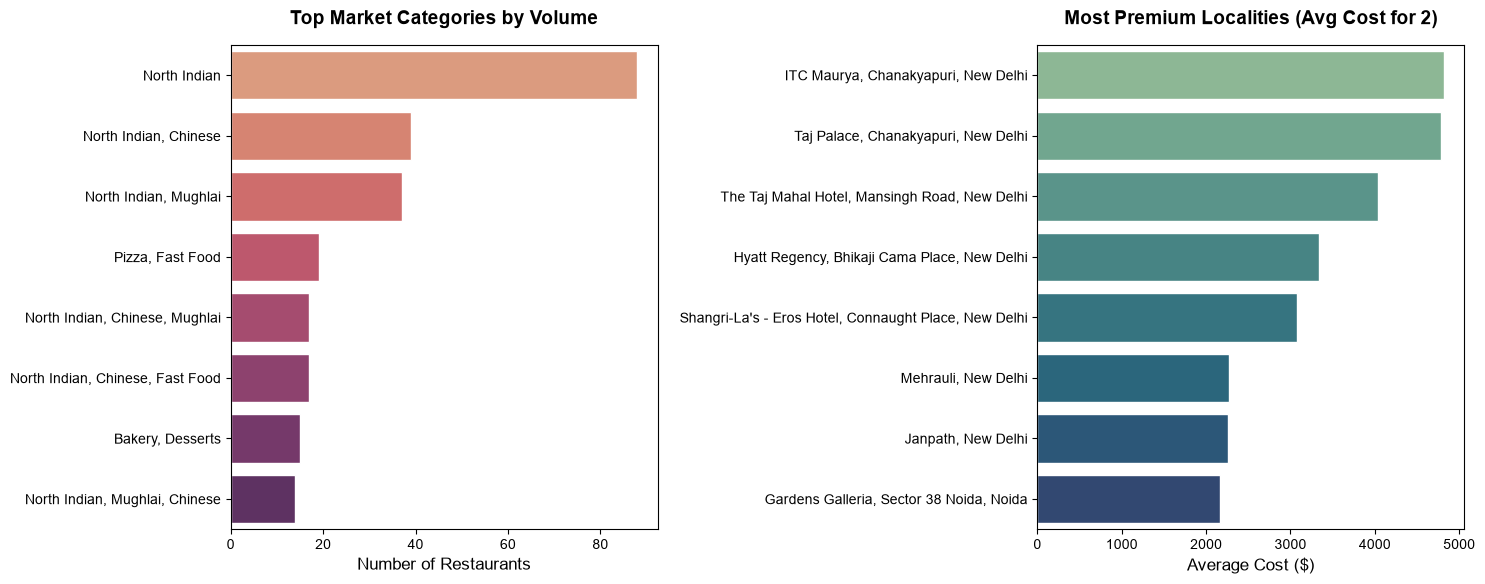

In [15]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Pull the data fresh from our SQL engine
conn = sqlite3.connect('delhi_zomato.db')
df_categories = pd.read_sql_query("""
    SELECT Category, COUNT(*) as Total FROM restaurants 
    GROUP BY Category HAVING Total >= 5 ORDER BY Total DESC LIMIT 8;
""", conn)

df_pricing = pd.read_sql_query("""
    SELECT Locality, AVG(Pricing_for_2) as Avg_Cost FROM restaurants 
    GROUP BY Locality HAVING COUNT(*) >= 5 ORDER BY Avg_Cost DESC LIMIT 8;
""", conn)
conn.close()

# 2. Initialize a beautiful 1-row, 2-column visual layout
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.set_theme(style="whitegrid")

# Left Chart: Market Share Volume
sns.barplot(data=df_categories, x='Total', y='Category', ax=axes[0], palette='flare', hue='Category', legend=False)
axes[0].set_title('Top Market Categories by Volume', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Number of Restaurants', fontsize=12)
axes[0].set_ylabel('')

# Right Chart: Premium Pricing Footprint
sns.barplot(data=df_pricing, x='Avg_Cost', y='Locality', ax=axes[1], palette='crest', hue='Locality', legend=False)
axes[1].set_title('Most Premium Localities (Avg Cost for 2)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Average Cost ($)', fontsize=12)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [17]:
import sqlite3
import pandas as pd

# Connect to your database
conn = sqlite3.connect('delhi_zomato.db')

# Force a clean pull of the Master data
df_master = pd.read_sql_query("SELECT * FROM restaurants;", conn)

# Force a clean pull of the Rankings data
df_rankings = pd.read_sql_query("""
    WITH Locality_Metrics AS (
        SELECT Locality, COUNT(*) as Restaurant_Count, AVG(Pricing_for_2) as Avg_Cost, MAX(Dining_Rating) as Highest_Rating
        FROM restaurants GROUP BY Locality HAVING Restaurant_Count >= 3
    )
    SELECT Locality, Restaurant_Count, Avg_Cost, Highest_Rating,
           DENSE_RANK() OVER (ORDER BY Avg_Cost DESC) as Market_Expense_Rank
    FROM Locality_Metrics;
""", conn)

# Explicitly strip whitespace and force string types for the joining keys
df_master['Locality'] = df_master['Locality'].astype(str).str.strip()
df_rankings['Locality'] = df_rankings['Locality'].astype(str).str.strip()

# Drop any accidental duplicates in the rankings file
df_rankings = df_rankings.drop_duplicates(subset=['Locality'])

# Save them as brand new files
df_master.to_csv('PowerBI_Master_Final.csv', index=False, encoding='utf-8')
df_rankings.to_csv('PowerBI_Rankings_Final.csv', index=False, encoding='utf-8')

conn.close()
print("Files saved successfully: 'PowerBI_Master_Final.csv' and 'PowerBI_Rankings_Final.csv'")

Files saved successfully: 'PowerBI_Master_Final.csv' and 'PowerBI_Rankings_Final.csv'
